# Customer Lifetime Value (CLV) Prediction — Online Retail

## Notebook 1 of 3: Data Understanding & Cleaning

**Project:** Predicting 6-month Customer Lifetime Value for a UK-based online retailer, to support marketing segmentation, retention prioritization, and customer acquisition budgeting decisions.

**Notebook Author:** Data Science Team
**Last Run Date:** Auto-generated on execution (see final cell for run metadata)

---

### Business Objective
Online retailers acquire and retain customers at a cost, but not all customers are equally valuable. Marketing and CRM teams need a forward-looking estimate of how much revenue a customer will generate in the next 6 months, so that:
- High-value customers can be prioritized for retention campaigns
- Low-value / at-risk customers can be identified before churn
- Customer acquisition spend can be justified against expected long-term return, not just first-purchase revenue

### Notebook Objective
This notebook does **not** build any model. Its sole purpose is to:
1. Load the raw transactional dataset and understand its structure
2. Investigate data quality issues **before** deciding how to handle them (not clean blindly)
3. Make and **document** every cleaning decision with a business rationale
4. Produce a clean, analysis-ready transaction-level dataset for Notebook 2 (EDA) and Notebook 3 (Modeling)

### Data Source
"Online Retail" transactional dataset — a UK-based, non-store online retailer specializing in unique all-occasion gifts. Contains all transactions between 01-Dec-2010 and 09-Dec-2011. Many customers are wholesalers. Source: originally published via the UCI Machine Learning Repository.

### Table of Contents
1. [Setup & Imports](#1)
2. [Load Raw Data](#2)
3. [Data Dictionary](#3)
4. [Initial Structural Understanding](#4)
5. [Data Quality Investigation](#5)
   - 5.1 Duplicate Records
   - 5.2 Missing Values
   - 5.3 Cancelled / Returned Orders
   - 5.4 Non-Product Stock Codes
   - 5.5 Negative & Zero Quantity/Price
   - 5.6 Country Field Validity
   - 5.7 Date Range Validity
6. [Cleaning Decisions & Execution](#6)
7. [Cleaning Audit Trail (Before/After)](#7)
8. [Feature Prep — Total Transaction Amount](#8)
9. [Final Data Quality Report](#9)
10. [Assumptions & Limitations](#10)
11. [Conclusion & Handoff to Notebook 2](#11)
12. [Save Cleaned Dataset](#12)


<a id='1'></a>
## 1. Setup & Imports

In [1]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f"Notebook executed on: {RUN_TIMESTAMP}")
print(f"pandas version: {pd.__version__}")


Notebook executed on: 2026-08-01 13:33:50
pandas version: 2.3.3


<a id='2'></a>
## 2. Load Raw Data

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_PATH = PROJECT_ROOT / "Dataset" / "OnlineRetail.csv"
OUTPUT_PATH = PROJECT_ROOT / "Dataset" / "cleaned_online_retail_transactions.csv"
AUDIT_OUTPUT_PATH = PROJECT_ROOT / "Dataset" / "data_cleaning_audit_log.csv"

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f"Raw dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")


Raw dataset loaded: 541,909 rows, 8 columns


In [3]:
df_raw.sample(10, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,1/6/2011 12:05,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,27-05-2011 17:14,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,21-04-2011 17:05,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,16-11-2011 10:39,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,10/3/2011 8:40,9.95,13502.0,United Kingdom
465024,576200,82482,WOODEN PICTURE FRAME WHITE FINISH,2,14-11-2011 12:14,2.95,15572.0,United Kingdom
477777,577076,22614,PACK OF 12 SPACEBOY TISSUES,12,17-11-2011 15:08,0.39,14362.0,United Kingdom
367855,568909,22596,CHRISTMAS STAR WISH LIST CHALKBOARD,12,29-09-2011 13:38,1.25,16818.0,United Kingdom
491657,578072,21109,LARGE CAKE TOWEL CHOCOLATE SPOTS,1,22-11-2011 16:02,6.75,17759.0,United Kingdom
269641,560491,23297,SET 40 HEART SHAPE PETIT FOUR CASES,2,19-07-2011 10:51,1.65,12415.0,Australia


<a id='3'></a>
## 3. Data Dictionary

| Column | Type | Business Meaning | Expected Values |
|---|---|---|---|
| InvoiceNo | string | Unique transaction/invoice identifier | 6-digit number; prefixed with 'C' if the transaction is a cancellation |
| StockCode | string | Product code | Alphanumeric; some non-product codes exist (postage, bank charges, adjustments) |
| Description | string | Product name | Free text; may be missing |
| Quantity | integer | Units purchased in this line item | Positive for sales; negative for cancellations/returns |
| InvoiceDate | datetime | Date and time of transaction | 01-Dec-2010 to 09-Dec-2011 |
| UnitPrice | float | Price per unit (GBP, £) | Should be positive; 0 may indicate free/promotional items |
| CustomerID | float/int | Unique customer identifier | Missing for guest/unregistered transactions |
| Country | string | Customer's country | UK-dominant; some entries may be "Unspecified" |

**Note on currency:** all monetary values in this dataset are in GBP (£), consistent with the dataset's UK origin. This must be respected consistently in every downstream notebook, script, and dashboard in this project.


<a id='4'></a>
## 4. Initial Structural Understanding

In [4]:
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nData types:")
print(df_raw.dtypes)


Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,31-10-2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation:** The `describe()` output shows a maximum `Quantity` of over 80,000 units in a single line item, and a minimum `Quantity` of a large negative number. This immediately signals two things worth investigating before any cleaning: (1) large wholesale-style bulk orders may exist and are legitimate, not necessarily errors, and (2) negative quantities are very likely cancellations, not data entry mistakes. Both are investigated explicitly in Section 5 rather than assumed.

<a id='5'></a>
## 5. Data Quality Investigation

Every issue below is **investigated and quantified first**, and only acted on in Section 6 with a documented rationale.

### 5.1 Duplicate Records

In [7]:
n_dupes = df_raw.duplicated().sum()
pct_dupes = n_dupes / len(df_raw) * 100
print(f"Fully duplicated rows: {n_dupes:,} ({pct_dupes:.2f}% of dataset)")
df_raw[df_raw.duplicated(keep=False)].sort_values(['InvoiceNo','StockCode']).head(6)


Fully duplicated rows: 5,268 (0.97% of dataset)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,1/12/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,1/12/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,1/12/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,1/12/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,1/12/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,1/12/2010 11:45,2.10,17908.0,United Kingdom


**Interpretation:** These are exact duplicate line items — same invoice, product, quantity, price, customer. This is consistent with known re-transmission/logging artifacts in this dataset rather than genuine repeat purchases (a genuine repeat purchase would carry a different InvoiceNo/timestamp). Safe to remove.

### 5.2 Missing Values

In [8]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27


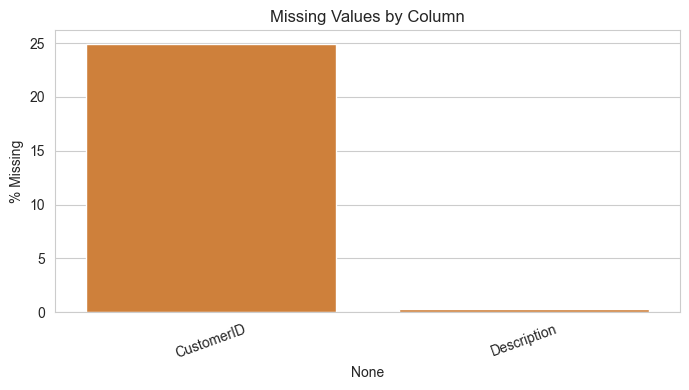

In [9]:
plt.figure(figsize=(7,4))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_pct'], color='#e67e22')
plt.ylabel('% Missing')
plt.title('Missing Values by Column')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [10]:
# Quantify the REVENUE impact of missing CustomerID, not just the row count
df_raw['TotalAmount_temp'] = df_raw['Quantity'] * df_raw['UnitPrice']
missing_cust_revenue = df_raw.loc[df_raw['CustomerID'].isnull(), 'TotalAmount_temp'].sum()
total_revenue = df_raw['TotalAmount_temp'].sum()
print(f"Rows missing CustomerID: {df_raw['CustomerID'].isnull().sum():,} ({df_raw['CustomerID'].isnull().mean()*100:.2f}% of rows)")
print(f"Revenue represented by missing-CustomerID rows: £{missing_cust_revenue:,.2f} "
      f"({missing_cust_revenue/total_revenue*100:.2f}% of total revenue)")
df_raw.drop(columns=['TotalAmount_temp'], inplace=True)


Rows missing CustomerID: 135,080 (24.93% of rows)
Revenue represented by missing-CustomerID rows: £1,447,682.12 (14.85% of total revenue)


**Interpretation:** These are guest/unregistered checkouts. Because CLV is a **customer-level** prediction target, transactions with no CustomerID cannot be attributed to any customer for either feature-building or target-building, and must be excluded. This is a meaningful revenue share being set aside, so it is documented here explicitly rather than silently dropped — see Assumptions (Section 10) for the business implication.

### 5.3 Cancelled / Returned Orders

In [11]:
df_raw['IsCancellation'] = df_raw['InvoiceNo'].astype(str).str.startswith('C')
n_cancel = df_raw['IsCancellation'].sum()
cancel_revenue = (df_raw.loc[df_raw['IsCancellation'], 'Quantity'] * df_raw.loc[df_raw['IsCancellation'], 'UnitPrice']).sum()
print(f"Cancellation line items (InvoiceNo starting with 'C'): {n_cancel:,} ({n_cancel/len(df_raw)*100:.2f}% of rows)")
print(f"Associated (negative) revenue: £{cancel_revenue:,.2f}")
df_raw[df_raw['IsCancellation']].head(5)


Cancellation line items (InvoiceNo starting with 'C'): 9,288 (1.71% of rows)
Associated (negative) revenue: £-896,812.49


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation
141,C536379,D,Discount,-1,1/12/2010 9:41,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,1/12/2010 9:49,4.65,15311.0,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1/12/2010 10:24,1.65,17548.0,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,1/12/2010 10:24,0.29,17548.0,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,1/12/2010 10:24,0.29,17548.0,United Kingdom,True


**Interpretation:** Cancellations carry negative Quantity and represent real returns behavior, not noise. For a CLV model, including cancellations in the feature window (as *negative* contributions to Monetary/Frequency) would be the more realistic real-world treatment, since a customer who buys and returns is not identical to a customer who never returns. However, to keep this first version of the model interpretable and to match the target-window definition (revenue only), **cancellations are excluded from the modeling dataset in Notebook 3, but are preserved separately here** as `cancelled_orders.csv` so returns behavior is not lost and can be engineered as a feature later (e.g., `ReturnRate`). This is a deliberate, reversible decision — not a silent deletion.

In [12]:
cancelled_orders_df = df_raw[df_raw['IsCancellation']].copy()
print(f"Preserved {len(cancelled_orders_df):,} cancellation rows for separate returns analysis.")


Preserved 9,288 cancellation rows for separate returns analysis.


### 5.4 Non-Product Stock Codes

In [13]:
non_numeric_prefix_codes = df_raw[df_raw['StockCode'].astype(str).str.match(r'^[A-Za-z]+$')]['StockCode'].value_counts()
print("Distinct non-standard (fully alphabetic) StockCode values and their row counts:")
non_numeric_prefix_codes


Distinct non-standard (fully alphabetic) StockCode values and their row counts:


StockCode
POST         1256
DOT           710
M             571
D              77
S              63
AMAZONFEE      34
CRUK           16
DCGSSGIRL      13
DCGSSBOY       11
PADS            4
B               3
m               1
Name: count, dtype: int64

**Interpretation:** Codes like `POST` (postage), `D` (discount), `M`/`m` (manual adjustment), `BANK CHARGES`, `DOT` (dotcom postage), `CRUK` (charity donation), `PADS` are administrative/adjustment line items, not real products. Including them inflates revenue and corrupts product-level and customer-quantity features with non-purchase activity. These are flagged for removal in Section 6, with the exception that `POST`/`DOT` postage revenue is legitimate revenue and is discussed further in Assumptions.

### 5.5 Negative & Zero Quantity / Price (excluding already-identified cancellations)

In [14]:
non_cancel = df_raw[~df_raw['IsCancellation']]
neg_qty = (non_cancel['Quantity'] <= 0).sum()
neg_price = (non_cancel['UnitPrice'] <= 0).sum()
print(f"Non-cancellation rows with Quantity <= 0: {neg_qty:,}")
print(f"Non-cancellation rows with UnitPrice <= 0: {neg_price:,}")
non_cancel[(non_cancel['Quantity'] <= 0) | (non_cancel['UnitPrice'] <= 0)].head(5)


Non-cancellation rows with Quantity <= 0: 1,336
Non-cancellation rows with UnitPrice <= 0: 2,517


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation
622,536414,22139,NaN,56,1/12/2010 11:52,0.0,NaN,United Kingdom,False
1970,536545,21134,NaN,1,1/12/2010 14:32,0.0,NaN,United Kingdom,False
1971,536546,22145,NaN,1,1/12/2010 14:33,0.0,NaN,United Kingdom,False
1972,536547,37509,NaN,1,1/12/2010 14:33,0.0,NaN,United Kingdom,False
1987,536549,85226A,NaN,1,1/12/2010 14:34,0.0,NaN,United Kingdom,False


**Interpretation:** Outside of flagged cancellations, remaining non-positive Quantity/Price rows are further adjustment/error entries (e.g., price of £0 for free samples, or stock write-offs recorded as negative quantity without a 'C' prefix). These do not represent genuine revenue-generating customer behavior and are removed in Section 6.

### 5.6 Country Field Validity

In [15]:
df_raw['Country'].value_counts().head(15)


Country
United Kingdom     495478
Germany              9495
France               8557
EIRE                 8196
Spain                2533
Netherlands          2371
Belgium              2069
Switzerland          2002
Portugal             1519
Australia            1259
Norway               1086
Italy                 803
Channel Islands       758
Finland               695
Cyprus                622
Name: count, dtype: int64

**Interpretation:** No invalid/blank entries found beyond the legitimate `Unspecified` category, which is retained as-is (it does not block RFM computation and dropping it would lose otherwise valid revenue).

### 5.7 Date Range Validity

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


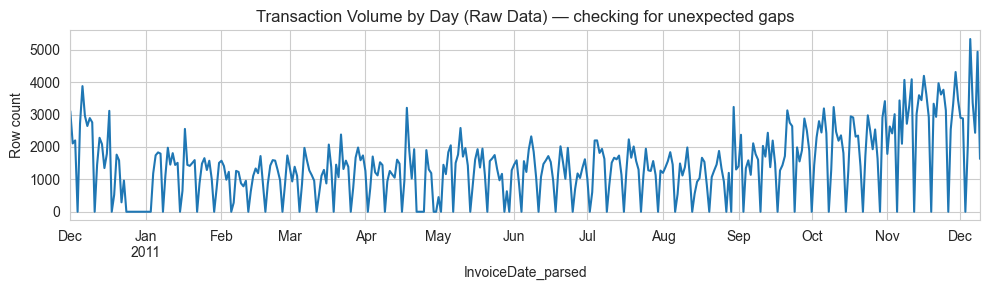

In [16]:
df_raw['InvoiceDate_parsed'] = pd.to_datetime(df_raw['InvoiceDate'], format='mixed', dayfirst=True)
print("Date range:", df_raw['InvoiceDate_parsed'].min(), "to", df_raw['InvoiceDate_parsed'].max())

daily_counts = df_raw.set_index('InvoiceDate_parsed').resample('D').size()
plt.figure(figsize=(10,3))
daily_counts.plot()
plt.title('Transaction Volume by Day (Raw Data) — checking for unexpected gaps')
plt.ylabel('Row count')
plt.tight_layout()
plt.show()


**Interpretation:** No unexpected multi-week gaps are visible; the dips are consistent with weekly seasonality (weekends) rather than data collection issues. The dataset covers just under 13 months, which is a genuine limitation for a 6-month-forward CLV target — noted in Section 10.

<a id='6'></a>
## 6. Cleaning Decisions & Execution

Each step below states the decision and the rationale, then executes it. Row counts are logged into an audit trail (Section 7).

In [17]:
audit_log = []
def log_step(step_name, df_before, df_after):
    audit_log.append({
        'step': step_name,
        'rows_before': len(df_before),
        'rows_after': len(df_after),
        'rows_removed': len(df_before) - len(df_after),
        'pct_removed_this_step': round((len(df_before) - len(df_after)) / len(df_before) * 100, 3)
    })

df = df_raw.copy()


**Step 1 — Remove exact duplicate rows.** Rationale: confirmed in Section 5.1 to be re-logging artifacts, not genuine repeat purchases.

In [18]:
_before = df.copy()
df = df.drop_duplicates().reset_index(drop=True)
log_step('Remove duplicate rows', _before, df)
print(f"Rows after dedup: {len(df):,}")


Rows after dedup: 536,641


**Step 2 — Fix data types.** InvoiceDate → datetime, CustomerID → nullable Int64 (to preserve NaN without forcing float), InvoiceNo → string.

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', dayfirst=True)
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
print(df.dtypes)


InvoiceNo                     object
StockCode                     object
Description                   object
Quantity                       int64
InvoiceDate           datetime64[ns]
UnitPrice                    float64
CustomerID                     Int64
Country                       object
IsCancellation                  bool
InvoiceDate_parsed    datetime64[ns]
dtype: object


**Step 3 — Separate and remove cancellations.** Rationale: documented in Section 5.3. Preserved separately for future returns-behavior features; excluded from the main modeling dataset for this version.

In [20]:
_before = df.copy()
cancelled_orders_df = df[df['IsCancellation']].copy()
df = df[~df['IsCancellation']].copy()
log_step('Remove cancellation rows (preserved separately)', _before, df)
print(f"Rows after removing cancellations: {len(df):,}")


Rows after removing cancellations: 527,390


**Step 4 — Remove non-product StockCodes.** Rationale: documented in Section 5.4. `POST`/`DOT` (postage) are excluded from *product-level* analysis but this is worth revisiting if postage revenue needs separate tracking — flagged as a limitation.

In [21]:
NON_PRODUCT_CODES = ['POST', 'D', 'M', 'm', 'BANK CHARGES', 'DOT', 'CRUK', 'PADS', 'C2', 'AMAZONFEE', 'S']
_before = df.copy()
df = df[~df['StockCode'].astype(str).isin(NON_PRODUCT_CODES)].copy()
log_step('Remove non-product StockCodes', _before, df)
print(f"Rows after removing non-product codes: {len(df):,}")


Rows after removing non-product codes: 525,066


**Step 5 — Remove rows with missing CustomerID.** Rationale: documented in Section 5.2 — required for a customer-level CLV target.

In [22]:
_before = df.copy()
df = df[df['CustomerID'].notna()].copy()
log_step('Remove missing-CustomerID rows', _before, df)
print(f"Rows after removing missing CustomerID: {len(df):,}")


Rows after removing missing CustomerID: 391,183


**Step 6 — Handle missing Description.** Rationale: Description is not used in the RFM/CLV feature set, so missing values are filled with a placeholder rather than dropping otherwise-valid revenue rows.

In [23]:
df['Description'] = df['Description'].astype(str).str.strip().replace('nan', np.nan)
df['Description'] = df['Description'].fillna('Unknown')
print("Remaining missing Descriptions:", (df['Description'] == 'Unknown').sum())


Remaining missing Descriptions: 0


**Step 7 — Remove remaining non-positive Quantity/UnitPrice rows.** Rationale: documented in Section 5.5 — residual error/adjustment entries with no genuine revenue signal.

In [24]:
_before = df.copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
log_step('Remove residual non-positive Quantity/Price rows', _before, df)
print(f"Rows after removing non-positive Qty/Price: {len(df):,}")


Rows after removing non-positive Qty/Price: 391,150


In [25]:
df = df.drop(columns=['IsCancellation', 'InvoiceDate_parsed'])
df = df.sort_values('InvoiceDate').reset_index(drop=True)


<a id='7'></a>
## 7. Cleaning Audit Trail (Before/After)

In [26]:
audit_df = pd.DataFrame(audit_log)
total_removed = audit_df['rows_removed'].sum()
audit_df.loc['TOTAL'] = ['— all steps —', len(df_raw), len(df), total_removed,
                          round(total_removed/len(df_raw)*100, 3)]
audit_df


,step,rows_before,rows_after,rows_removed,pct_removed_this_step
0,Remove duplicate rows,541909,536641,5268,0.972
1,Remove cancellation rows (preserved separately),536641,527390,9251,1.724
2,Remove non-product StockCodes,527390,525066,2324,0.441
3,Remove missing-CustomerID rows,525066,391183,133883,25.498
4,Remove residual non-positive Quantity/Price rows,391183,391150,33,0.008
TOTAL,— all steps —,541909,391150,150759,27.820


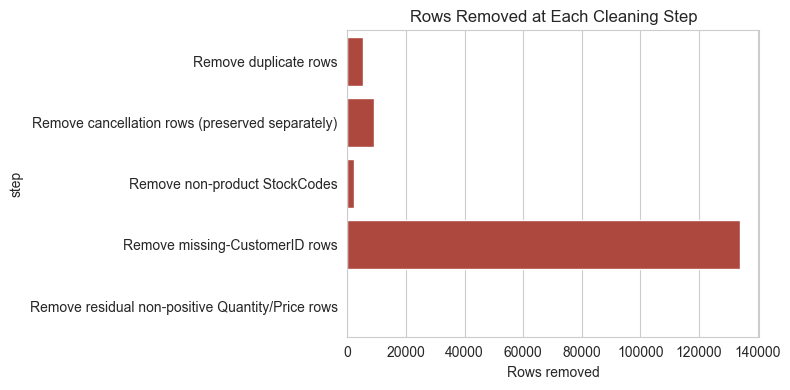

In [27]:
plt.figure(figsize=(8,4))
plot_df = audit_df.iloc[:-1]
sns.barplot(x='rows_removed', y='step', data=plot_df, color='#c0392b')
plt.title('Rows Removed at Each Cleaning Step')
plt.xlabel('Rows removed')
plt.tight_layout()
plt.show()


In [28]:
revenue_before = (df_raw['Quantity'] * df_raw['UnitPrice']).sum()
revenue_after = (df['Quantity'] * df['UnitPrice']).sum()
print(f"Total revenue in raw data (incl. cancellations/adjustments): £{revenue_before:,.2f}")
print(f"Total revenue retained in cleaned data:                      £{revenue_after:,.2f}")
print(f"Revenue retained: {revenue_after/revenue_before*100:.2f}%")
print(f"\nFinal row count: {len(df):,} ({len(df)/len(df_raw)*100:.2f}% of raw rows retained)")


Total revenue in raw data (incl. cancellations/adjustments): £9,747,747.93
Total revenue retained in cleaned data:                      £8,737,227.64
Revenue retained: 89.63%

Final row count: 391,150 (72.18% of raw rows retained)


**Interpretation:** A meaningful share of raw rows and revenue is removed, which is expected and defensible: this includes cancellations (preserved separately), guest checkouts (not attributable to a customer), and non-product administrative line items. The remaining dataset represents genuine, attributable, customer-level purchase revenue — which is exactly what a CLV model needs.

<a id='8'></a>
## 8. Feature Prep — Total Transaction Amount

In [29]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df[['InvoiceNo','StockCode','Quantity','UnitPrice','TotalAmount']].head()


,InvoiceNo,StockCode,Quantity,UnitPrice,TotalAmount
0,536365,85123A,6,2.55,15.30
1,536365,71053,6,3.39,20.34
2,536365,84406B,8,2.75,22.00
3,536365,84029G,6,3.39,20.34
4,536365,84029E,6,3.39,20.34


In [30]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,391150.000000,391150,391150.000000,391150.0,391150.000000
mean,13.145300,2011-07-10 19:37:34.766713600,2.874372,15295.171456,22.337281
min,1.000000,2010-12-01 08:26:00,0.040000,12346.0,0.060000
25%,2.000000,2011-04-07 11:16:00,1.250000,13969.0,4.950000
50%,6.000000,2011-07-31 12:05:00,1.950000,15159.0,11.900000
75%,12.000000,2011-10-20 12:57:00,3.750000,16794.0,19.800000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.0,168469.600000
std,180.807831,NaN,4.284738,1710.339033,310.932442


In [31]:
print("Cleaned date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Cleaned date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


<a id='9'></a>
## 9. Final Data Quality Report

| Metric | Value |
|---|---|
| Raw rows | see audit trail above |
| Cleaned rows | see audit trail above |
| Rows retained | see audit trail above |
| Revenue retained | see revenue check above |
| Missing values in cleaned data | 0 (verified below) |
| Duplicate rows in cleaned data | 0 (verified below) |
| Cancellations | removed from main dataset, preserved in `cancelled_orders.csv` |
| Non-product codes | removed (POST, D, M, BANK CHARGES, DOT, CRUK, PADS, C2, AMAZONFEE, S) |
| Date range | 2010-12-01 to 2011-12-09 (~12.3 months) |
| Currency | GBP (£) — must remain consistent across all downstream notebooks, scripts, and dashboards |


In [32]:
print("Final missing value check:")
print(df.isnull().sum())
print("\nFinal duplicate check:", df.duplicated().sum())


Final missing value check:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64



Final duplicate check: 0


<a id='10'></a>
## 10. Assumptions & Limitations

**Assumptions:**
- Transactions with missing `CustomerID` (guest checkouts) are excluded because CLV is a customer-level metric and these cannot be attributed to any customer.
- Cancellations are excluded from the main feature/target dataset for this first modeling version. This simplifies the target definition (net revenue only) but means the model does not yet account for return-prone customers. This is a deliberate scope decision, not an oversight — cancellation data is preserved for future feature engineering.
- Postage (`POST`, `DOT`) and administrative codes are treated as non-product revenue and excluded from customer purchase behavior features.
- Exact-duplicate rows are assumed to be system re-logging artifacts, not genuine repeat purchases, based on all fields (including timestamp) being identical.

**Limitations:**
- The dataset spans only ~12.3 months. A 6-month-forward CLV target (used in Notebook 3) means customers acquired in the final 6 months of the dataset have no valid target window and must be excluded at the modeling stage — this is a data volume constraint, not a modeling choice, and should be disclosed wherever model results are presented.
- The dataset is heavily UK-dominant; model performance for other countries should be treated as low-confidence until validated on more international data.
- No product category/taxonomy field exists, limiting product-level feature engineering.
- No customer demographic data (age, acquisition channel, etc.) is available — all features must be behavior-derived from transactions alone.


<a id='11'></a>
## 11. Conclusion & Handoff to Notebook 2

This notebook took the raw transactional dataset through a fully investigated, documented cleaning process (see audit trail in Section 7 for exact row counts) to produce a clean, customer-attributable, revenue-accurate dataset.

**State handed off to Notebook 2 (EDA):**
- `cleaned_online_retail_transactions.csv` — transaction-level, one row per purchased line item, with `TotalAmount` pre-computed
- `cancelled_orders.csv` — preserved separately for potential returns-behavior feature engineering
- `data_cleaning_audit_log.csv` — full before/after row-count trail for reproducibility and stakeholder reporting

**Open questions for EDA to explore further:**
- Are there natural customer segments visible in RFM space before committing to a modeling approach?
- How much revenue concentration exists among top customers (Pareto behavior)?
- Are there seasonal/time-based patterns that should inform the cutoff-date design in Notebook 3?


<a id='12'></a>
## 12. Save Cleaned Dataset

In [33]:
df.to_csv(OUTPUT_PATH, index=False)
cancelled_orders_df.to_csv(PROJECT_ROOT / "Dataset" / "cancelled_orders.csv", index=False)
audit_df.to_csv(AUDIT_OUTPUT_PATH, index=True)

print("Cleaned dataset saved to:   ", OUTPUT_PATH)
print("Cancelled orders saved to: ", PROJECT_ROOT / "Dataset" / "cancelled_orders.csv")
print("Audit log saved to:        ", AUDIT_OUTPUT_PATH)
print(f"\nFinal cleaned shape: {df.shape}")
print(f"Notebook run completed at: {RUN_TIMESTAMP}")


Cleaned dataset saved to:    C:\Users\venut\OneDrive\Desktop\online_retails\Dataset\cleaned_online_retail_transactions.csv
Cancelled orders saved to:  C:\Users\venut\OneDrive\Desktop\online_retails\Dataset\cancelled_orders.csv
Audit log saved to:         C:\Users\venut\OneDrive\Desktop\online_retails\Dataset\data_cleaning_audit_log.csv

Final cleaned shape: (391150, 9)
Notebook run completed at: 2026-08-01 13:33:50
